In [22]:
# Importing Libraries
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from adjustText import adjust_text
from matplotlib.ticker import PercentFormatter


# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else x
)

Found cached dataset csv (C:/Users/theim/.cache/huggingface/datasets/lukebarousse___csv/lukebarousse--data_jobs-20095235c13fb98d/0.0.0/6954658bab30a358235fa864b05cf819af0e179325c740e4bc853bcc7ec513e1)


  0%|          | 0/1 [00:00<?, ?it/s]

In [2]:
df_US_DA = df[
    (df['job_country'] == 'United States') & (df['job_title_short'] == 'Data Analyst')
].copy()

In [3]:
df_US_DA = df_US_DA.dropna(subset=['salary_year_avg'])

In [4]:
df_skills_exploded = df_US_DA.explode('job_skills')

In [5]:
# Calculate the average salary and job count of job postings per skill, and limit top skills
skills_count = df_skills_exploded.groupby('job_skills').agg(
    median_salary=('salary_year_avg', 'median'),
    skill_count=('salary_year_avg', 'size')
).sort_values(by='skill_count', ascending=False)

# Total number of job postings for each job title
total_jobs = df_US_DA.groupby('job_title_short').size()

In [6]:
# Get percent of jobs skills appear in
skills_count['skill_percent'] = round(skills_count['skill_count'].div(total_jobs[0]) * 100, 1)

top_skills = 12
skills_count = skills_count.head(top_skills)

In [31]:
# Define the categories
skill_categories = {
    # Programming
    'python': 'programming',
    'r': 'programming',
    'sql': 'programming',

    # Analyst Tools
    'excel': 'analyst_tools',
    'tableau': 'analyst_tools',
    'power bi': 'analyst_tools',
    'powerpoint': 'analyst_tools',
    'word': 'analyst_tools',

    # Databases
    'sql server': 'databases',
    'go': 'databases',
    'sas': 'databases',

    # Cloud (none in your current list, but ready for future skills)
    'oracle': 'cloud',
    # 'aws': 'cloud',
    # 'azure': 'cloud',
    # 'gcp': 'cloud',
}

skills_count['skill_category'] = skills_count.index.str.lower().map(skill_categories)

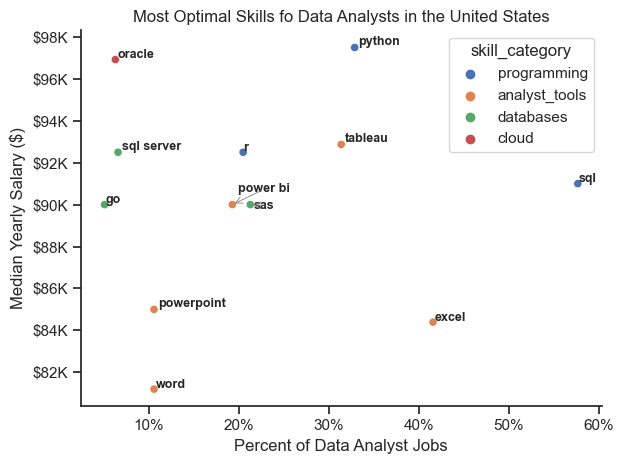

In [32]:
sns.set_theme(style='ticks')
ax = plt.gca()

sns.scatterplot(
    data=skills_count,
    x='skill_percent',
    y='median_salary',
    hue='skill_category',
    ax=ax
)

# Format axis
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
ax.yaxis.set_major_formatter(plt.FuncFormatter(
    lambda  y, pos: f'${int(y/1000)}K'
))

# Create text labels
texts =[]
for i, txt in enumerate(skills_count.index):
    texts.append(
        ax.text(
        skills_count['skill_percent'].iloc[i],
        skills_count['median_salary'].iloc[i],
        txt,
        fontsize=9,
        fontweight='bold'
        )
    )

# Adjust text position using adjustText
adjust_text(
    texts,
    ax=ax,
    expand_points=(1.2, 1.2),   # optional: gives a bit more space
    arrowprops=dict(arrowstyle='->', color='gray', lw=0.6)
    
)

sns.despine()

# Clean up visualization
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Yearly Salary ($)')
plt.title('Most Optimal Skills fo Data Analysts in the United States')
plt.tight_layout()

plt.show()